In [ ]:
# ===== Setup, mount, imports, seeds, folders =====

from google.colab import drive
drive.mount('/content/drive')

# Project root (same as your other notebooks)
PROJ = "/content/drive/MyDrive/Imbalance"

%cd $PROJ

import os, json, math, random, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, ConcatDataset, TensorDataset, Dataset
import torchvision

from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, precision_recall_fscore_support
import pandas as pd

# Make sure folders exist
for d in ["ckpts", "metrics", "figures", "splits"]:
    os.makedirs(os.path.join(PROJ, d), exist_ok=True)

# Reproducibility
SEED = 0
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Imbalance
Device: cuda


In [ ]:
# ===== Config, CIFAR-10, LT/SS/AS splits, test loader =====

CONFIG = {
    # AE (DeepSMOTE) settings
    "ae_epochs": 20,
    "ae_latent_dim": 600,
    "ae_lambda": 0.1,
    "ae_batch_size": 128,

    # DeepSMOTE oversampling target (fraction of max real count)
    # 1.0 = full top-up to max; 0.8 = 80% of max, etc.
    "target_ratio": 0.8,

    # Classifier training
    "cls_epochs": 50,
    "cls_batch_size": 128,
    "cls_lr": 0.1,
    "cls_weight_decay": 5e-4,
    "use_focal": True,
    "focal_gamma": 1.5,

    # Scenarios & models
    "include_lt": True,
    "include_ss": True,
    "include_as": True,
    "backbones": ["resnet18", "densenet121"],

    "num_workers": 2
}
print(CONFIG)

# Transforms (same as your baseline)
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),  # ~[-1,1]
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
])

# CIFAR-10 data
train_data = datasets.CIFAR10("./dataset_cache", train=True, download=True, transform=train_tf)
test_data  = datasets.CIFAR10("./dataset_cache", train=False, download=True, transform=test_tf)
class_labels = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
num_classes = 10

# Load splits/lt.json, splits/ss.json, splits/as.json
SPLITS = {}
for scn in ["lt","ss","as"]:
    p = os.path.join("splits", f"{scn}.json")
    if os.path.exists(p):
        with open(p) as f:
            data = json.load(f)
        SPLITS[scn] = {
            "indices": data["indices"],
            "counts": {int(k): int(v) for k,v in data["counts"].items()}
        }
        print(f"Loaded split '{scn.upper()}': {len(SPLITS[scn]['indices'])} images")
    else:
        print(f"WARNING: {p} not found.")

assert len(SPLITS) > 0, "No splits found. Run your data_split notebook first."

# Test loader (shared)
test_loader = DataLoader(
    test_data, batch_size=256, shuffle=False,
    num_workers=CONFIG["num_workers"], pin_memory=True
)

NUM_WORKERS = CONFIG["num_workers"]
BATCH_AE    = CONFIG["ae_batch_size"]
BATCH_CLS   = CONFIG["cls_batch_size"]


{'ae_epochs': 20, 'ae_latent_dim': 600, 'ae_lambda': 0.1, 'ae_batch_size': 128, 'target_ratio': 0.8, 'cls_epochs': 50, 'cls_batch_size': 128, 'cls_lr': 0.1, 'cls_weight_decay': 0.0005, 'use_focal': True, 'focal_gamma': 1.5, 'include_lt': True, 'include_ss': True, 'include_as': True, 'backbones': ['resnet18', 'densenet121'], 'num_workers': 2}
Loaded split 'LT': 16191 images
Loaded split 'SS': 27500 images
Loaded split 'AS': 9500 images


In [ ]:
# =====  DeepSMOTE Autoencoder (encoder + decoder) =====

class DeepSMOTEAutoencoder(nn.Module):
    def __init__(self, latent_dim=600):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: 3x32x32 -> latent
        self.enc = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),      # 64 x 16 x 16
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),    # 128 x 8 x 8
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),   # 256 x 4 x 4
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1),   # 512 x 2 x 2
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.enc_fc = nn.Linear(512 * 2 * 2, latent_dim)

        # Decoder: latent -> 3x32x32
        self.dec_fc = nn.Linear(latent_dim, 512 * 2 * 2)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1), # 256 x 4 x 4
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1), # 128 x 8 x 8
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 64 x 16 x 16
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),    # 3 x 32 x 32
            nn.Tanh(),  # output in [-1, 1]
        )

    def encode(self, x):
        h = self.enc(x)
        h = h.view(h.size(0), -1)
        z = self.enc_fc(h)
        return z

    def decode(self, z):
        h = self.dec_fc(z)
        h = h.view(h.size(0), 512, 2, 2)
        x_rec = self.dec(h)
        return x_rec

    def forward(self, x):
        z = self.encode(x)
        x_rec = self.decode(z)
        return z, x_rec


In [ ]:
# ===== Train AE for one scenario (LT / SS / AS) =====

from torch.utils.data import random_split

def train_ae_for_split(indices,
                       num_epochs=20,
                       latent_dim=600,
                       lambda_penalty=0.1,
                       batch_size=128,
                       val_frac=0.1):
    """
    Train DeepSMOTE autoencoder for a given scenario.
    Splits that scenario's data into AE-train / AE-val for monitoring.
    """
    full_subset = Subset(train_data, indices)
    n_total = len(full_subset)
    n_val = max(1, int(val_frac * n_total))
    n_train = n_total - n_val

    train_subset_ae, val_subset_ae = random_split(
        full_subset,
        [n_train, n_val],
        generator=torch.Generator().manual_seed(SEED)
    )

    train_loader = DataLoader(train_subset_ae, batch_size=batch_size, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_subset_ae,   batch_size=batch_size, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)

    print(f"AE training on {n_train} images, AE validation on {n_val} images.")

    ae = DeepSMOTEAutoencoder(latent_dim=latent_dim).to(device)
    recon_criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3, betas=(0.5, 0.999))

    for epoch in range(1, num_epochs+1):
        # --- TRAIN ---
        ae.train()
        running_train_loss, n_train_seen = 0.0, 0

        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            # reconstruction
            z, rec = ae(imgs)
            loss_recon = recon_criterion(rec, imgs)

            #permutation penalty within each class
            loss_penalty = 0.0
            unique_labels = labels.unique()
            for c in unique_labels:
                mask = (labels == c)
                cls_imgs = imgs[mask]
                if cls_imgs.size(0) < 2:
                    continue
                z_cls, _ = ae(cls_imgs)
                perm = torch.randperm(z_cls.size(0), device=device)
                z_perm = z_cls[perm]
                rec_perm = ae.decode(z_perm)
                loss_penalty = loss_penalty + recon_criterion(rec_perm, cls_imgs)

            loss = loss_recon + lambda_penalty * loss_penalty
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * imgs.size(0)
            n_train_seen += imgs.size(0)

        avg_train_loss = running_train_loss / n_train_seen

        # --- VAL ---
        ae.eval()
        running_val_loss, n_val_seen = 0.0, 0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(device)
                _, rec = ae(imgs)
                val_loss = recon_criterion(rec, imgs)
                running_val_loss += val_loss.item() * imgs.size(0)
                n_val_seen += imgs.size(0)

        avg_val_loss = running_val_loss / n_val_seen

        if epoch == 1 or epoch % 5 == 0 or epoch == num_epochs:
          print(f"[AE] Ep {epoch:03d} | train_loss={avg_train_loss:.4f} "
              f"| val_loss={avg_val_loss:.4f}")

    return ae


In [ ]:
# =====  Collect latents and generate DeepSMOTE samples =====

def collect_latents_per_class(ae_model, indices, batch_size=256, latent_dim=600):
    """
    Encode all images for this scenario, grouped by class.
    Returns: dict c -> [N_c, latent_dim] tensor
    """
    subset = Subset(train_data, indices)
    loader = DataLoader(subset, batch_size=batch_size, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

    ae_model.eval()
    latents_per_class = {c: [] for c in range(num_classes)}
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            z, _ = ae_model(imgs)
            z = z.cpu()
            for i in range(imgs.size(0)):
                c = int(labels[i].item())
                latents_per_class[c].append(z[i])

    for c in range(num_classes):
        if len(latents_per_class[c]) > 0:
            latents_per_class[c] = torch.stack(latents_per_class[c], dim=0)
        else:
            latents_per_class[c] = torch.empty(0, latent_dim)

    return latents_per_class


def deep_smote_generate(ae_model, latents_per_class, latent_dim=600, target_ratio=0.8):

    ae_model.eval()
    counts = {c: latents_per_class[c].shape[0] for c in range(num_classes)}
    max_real = max(counts.values())
    max_count = int(max_real * target_ratio)
    print("Original class counts:", counts)
    print("Target count per class:", max_count, f"(target_ratio={target_ratio})")

    synthetic_imgs = []
    synthetic_labels = []

    with torch.no_grad():
        for c in range(num_classes):
            z_cls = latents_per_class[c]
            n_current = z_cls.shape[0]
            if n_current == 0:
                print(f"WARNING: class {c} has 0 samples, skipping.")
                continue

            n_to_add = max_count - n_current
            if n_to_add <= 0:
                continue

            print(f"Class {c} ({class_labels[c]}): adding {n_to_add} synthetic samples")

            for _ in range(n_to_add):
                i = torch.randint(0, n_current, (1,)).item()
                j = torch.randint(0, n_current, (1,)).item()
                zi = z_cls[i]
                zj = z_cls[j]
                alpha = torch.rand(1).item()
                z_new = zi + alpha * (zj - zi)
                z_new = z_new.unsqueeze(0).to(device)
                x_new = ae_model.decode(z_new)    # [1,3,32,32]
                x_new = x_new.cpu().squeeze(0)
                synthetic_imgs.append(x_new)
                synthetic_labels.append(c)

    synthetic_imgs = torch.stack(synthetic_imgs, dim=0)
    synthetic_labels = torch.tensor(synthetic_labels, dtype=torch.long)
    print("Total synthetic images generated:", synthetic_imgs.shape[0])

    return synthetic_imgs, synthetic_labels


In [ ]:
# =====  Synthetic dataset wrapper (to match CIFAR-10 label type) =====

class SyntheticImageDataset(Dataset):
    def __init__(self, images, labels):
        """
        images: tensor [N, 3, 32, 32]
        labels: tensor [N] or list of ints
        """
        self.images = images
        self.labels = labels

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, idx):
        img = self.images[idx]
        lbl = int(self.labels[idx])  # make Python int, like CIFAR-10
        return img, lbl


In [ ]:
# ===== Classifiers (ResNet18 / DenseNet121), FocalLoss, training & metrics =====

# --- Models ---

def resnet18_cifar(num_classes=10):
    m = models.resnet18(weights=None)
    m.conv1 = nn.Conv2d(3,64,kernel_size=3,stride=1,padding=1,bias=False)
    m.maxpool = nn.Identity()
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

def densenet121_cifar(num_classes=10):
    m = torchvision.models.densenet121(weights=None)
    m.features.conv0 = nn.Conv2d(3,64,3,1,1,bias=False)
    m.features.pool0 = nn.Identity()
    m.classifier = nn.Linear(m.classifier.in_features, num_classes)
    return m




def make_model(backbone, num_classes=10):
    if backbone == "resnet18":
        return resnet18_cifar(num_classes)
    elif backbone == "densenet121":
        return densenet121_cifar(num_classes)
    else:
        raise ValueError(f"Unknown backbone: {backbone}")


# --- Focal loss ---

class FocalLoss(nn.Module):
    """
    Multi-class focal loss with logits.
    gamma > 0 focuses on hard examples.
    alpha: None -> no class weighting (we keep it simple here).
    """
    def __init__(self, gamma=2.0, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, weight=self.alpha, reduction="none")
        pt = torch.softmax(logits, dim=1).gather(1, target.view(-1,1)).squeeze(1).clamp_min(1e-8)
        loss = ((1-pt)**self.gamma) * ce
        if self.reduction=="mean":
            return loss.mean()
        elif self.reduction=="sum":
            return loss.sum()
        return loss


# --- Training & evaluation helpers ---

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    tot_loss, correct, n = 0.0, 0, 0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        pred = logits.argmax(1)
        correct += (pred == y).sum().item()
        tot_loss += loss.item() * x.size(0)
        n += x.size(0)
    return tot_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    tot_loss, correct, n = 0.0, 0, 0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        pred = logits.argmax(1)
        correct += (pred == y).sum().item()
        tot_loss += loss.item() * x.size(0)
        n += x.size(0)
    return tot_loss / n, correct / n


@torch.no_grad()
def get_preds(model, loader):
    model.eval()
    ys, ps = [], []
    for x,y in loader:
        x = x.to(device)
        pred = model(x).argmax(1).cpu().numpy()
        ys.append(y.numpy()); ps.append(pred)
    return np.concatenate(ys), np.concatenate(ps)


def confusion_matrix_custom(y_true, y_pred, K=10):
    cm = np.zeros((K,K), dtype=np.int64)
    for t,p in zip(y_true, y_pred):
        cm[t,p] += 1
    return cm

def macro_f1(cm):
    prec = np.diag(cm) / np.clip(cm.sum(0), 1, None)
    rec  = np.diag(cm) / np.clip(cm.sum(1), 1, None)
    f1   = 2 * prec * rec / np.clip(prec+rec, 1e-12, None)
    return float(np.nanmean(f1))

def balanced_acc(cm):
    rec  = np.diag(cm) / np.clip(cm.sum(1), 1, None)
    return float(np.nanmean(rec))



SCENARIO: LT  (num train images = 16191)
Class counts: {0: 5000, 1: 3500, 2: 2449, 3: 1714, 4: 1200, 5: 840, 6: 588, 7: 411, 8: 288, 9: 201}

>>> Training DeepSMOTE Autoencoder ...
AE training on 14572 images, AE validation on 1619 images.
[AE] Ep 001 | train_loss=0.5260 | val_loss=0.1583
[AE] Ep 005 | train_loss=0.3621 | val_loss=0.2345
[AE] Ep 010 | train_loss=0.3190 | val_loss=0.2875
[AE] Ep 015 | train_loss=0.3057 | val_loss=0.3013
[AE] Ep 020 | train_loss=0.2912 | val_loss=0.2908

>>> Collecting latents per class ...

>>> Generating DeepSMOTE synthetic images ...
Original class counts: {0: 5000, 1: 3500, 2: 2449, 3: 1714, 4: 1200, 5: 840, 6: 588, 7: 411, 8: 288, 9: 201}
Target count per class: 4000 (target_ratio=0.8)
Class 1 (automobile): adding 500 synthetic samples
Class 2 (bird): adding 1551 synthetic samples
Class 3 (cat): adding 2286 synthetic samples
Class 4 (deer): adding 2800 synthetic samples
Class 5 (dog): adding 3160 synthetic samples
Class 6 (frog): adding 3412 synthe

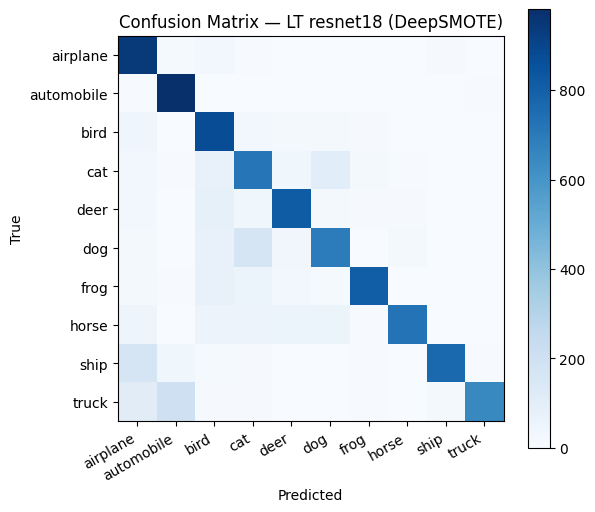

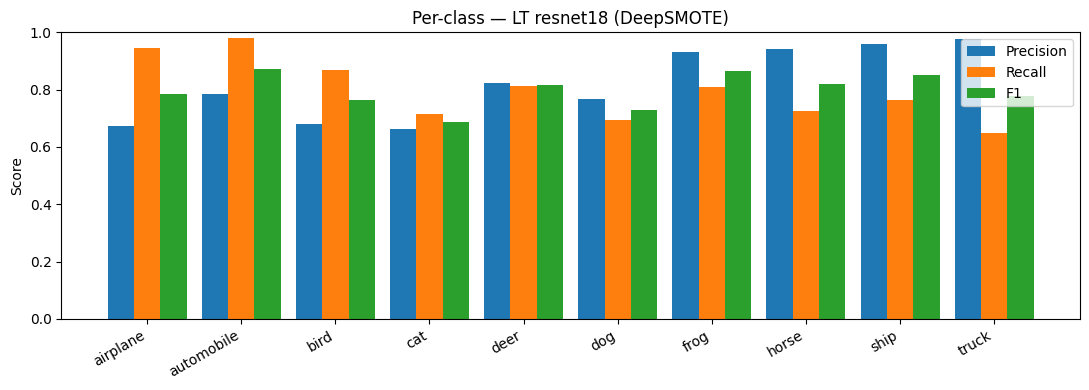


----------------------------------------------------------------------
LT | densenet121 | DeepSMOTE
[Epoch 001/50] train_loss=1.5582 acc=29.45% | val_loss=1.6518 acc=23.30%
[Epoch 005/50] train_loss=0.9929 acc=51.28% | val_loss=1.5438 acc=35.19%
[Epoch 010/50] train_loss=0.7553 acc=60.90% | val_loss=1.0976 acc=45.47%
[Epoch 015/50] train_loss=0.5807 acc=68.90% | val_loss=1.0117 acc=49.51%
[Epoch 020/50] train_loss=0.4546 acc=74.66% | val_loss=0.9740 acc=53.52%
[Epoch 025/50] train_loss=0.3262 acc=81.20% | val_loss=0.7261 acc=63.95%
[Epoch 030/50] train_loss=0.2018 acc=87.45% | val_loss=0.6471 acc=68.70%
[Epoch 035/50] train_loss=0.0899 acc=94.26% | val_loss=0.7084 acc=68.38%
[Epoch 040/50] train_loss=0.0336 acc=97.63% | val_loss=0.5147 acc=77.58%
[Epoch 045/50] train_loss=0.0113 acc=99.18% | val_loss=0.5451 acc=78.50%
[Epoch 050/50] train_loss=0.0061 acc=99.60% | val_loss=0.5282 acc=79.07%

TEST — Acc 79.52% | Macro-F1 79.58% | Balanced Acc 79.52%

--- Classification report: LT | dens

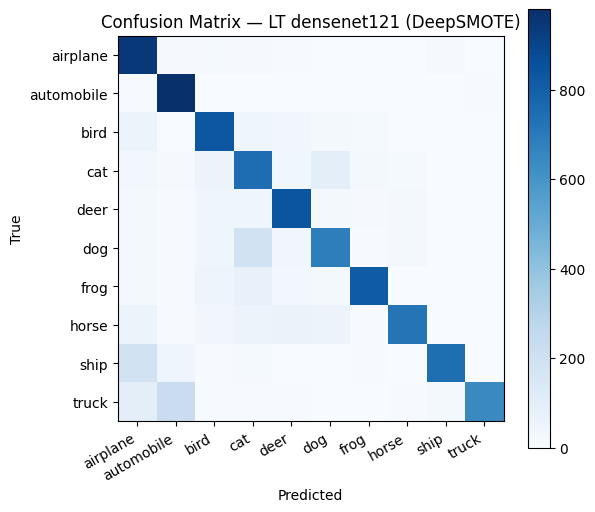

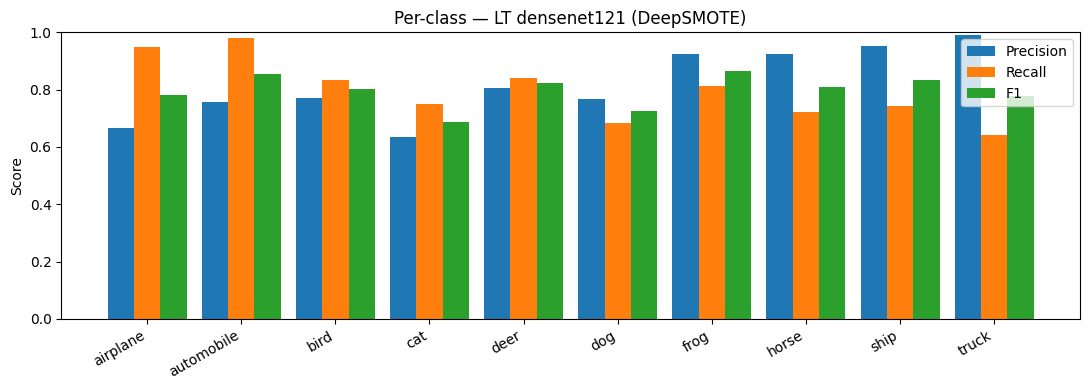


SCENARIO: SS  (num train images = 27500)
Class counts: {0: 5000, 1: 5000, 2: 5000, 3: 5000, 4: 5000, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500}

>>> Training DeepSMOTE Autoencoder ...
AE training on 24750 images, AE validation on 2750 images.
[AE] Ep 001 | train_loss=0.4684 | val_loss=0.1407
[AE] Ep 005 | train_loss=0.3222 | val_loss=0.2738
[AE] Ep 010 | train_loss=0.2851 | val_loss=0.2815
[AE] Ep 015 | train_loss=0.2729 | val_loss=0.2541
[AE] Ep 020 | train_loss=0.2687 | val_loss=0.3166

>>> Collecting latents per class ...

>>> Generating DeepSMOTE synthetic images ...
Original class counts: {0: 5000, 1: 5000, 2: 5000, 3: 5000, 4: 5000, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500}
Target count per class: 4000 (target_ratio=0.8)
Class 5 (dog): adding 3500 synthetic samples
Class 6 (frog): adding 3500 synthetic samples
Class 7 (horse): adding 3500 synthetic samples
Class 8 (ship): adding 3500 synthetic samples
Class 9 (truck): adding 3500 synthetic samples
Total synthetic images generated: 17

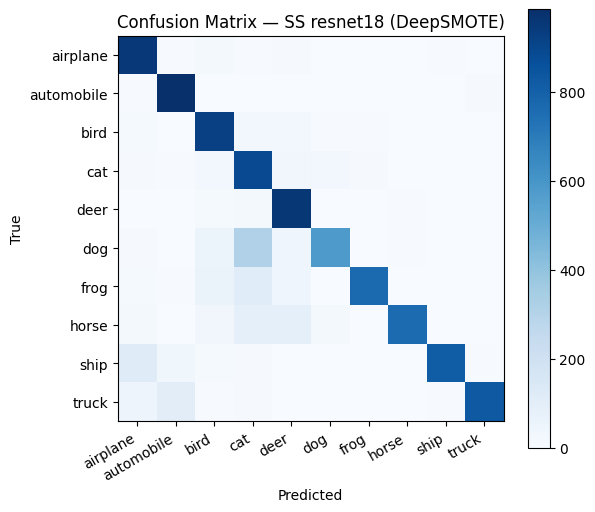

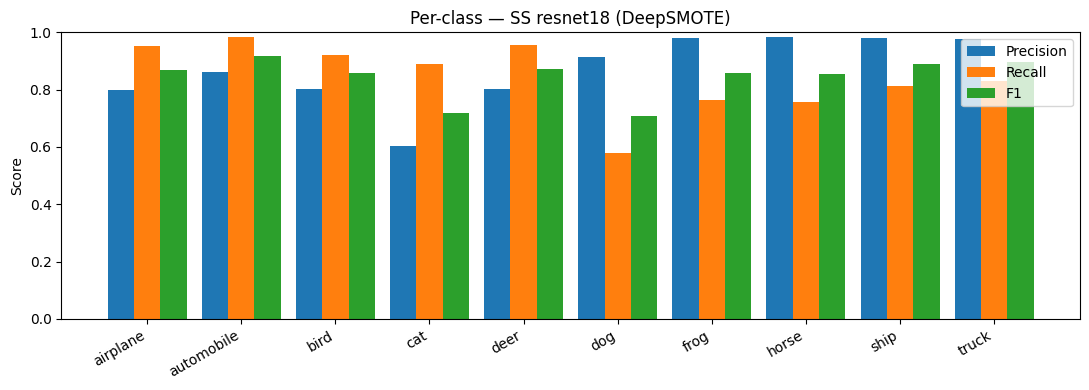


----------------------------------------------------------------------
SS | densenet121 | DeepSMOTE
[Epoch 001/50] train_loss=1.1486 acc=40.70% | val_loss=2.0860 acc=26.32%
[Epoch 005/50] train_loss=0.6383 acc=62.66% | val_loss=1.0431 acc=49.65%
[Epoch 010/50] train_loss=0.3907 acc=75.67% | val_loss=0.8244 acc=62.08%
[Epoch 015/50] train_loss=0.2747 acc=82.49% | val_loss=0.8436 acc=62.99%
[Epoch 020/50] train_loss=0.2096 acc=86.47% | val_loss=0.6747 acc=68.34%
[Epoch 025/50] train_loss=0.1562 acc=89.52% | val_loss=0.4903 acc=76.29%
[Epoch 030/50] train_loss=0.1006 acc=93.18% | val_loss=0.5254 acc=76.92%
[Epoch 035/50] train_loss=0.0534 acc=96.27% | val_loss=0.4848 acc=79.11%
[Epoch 040/50] train_loss=0.0150 acc=98.88% | val_loss=0.4365 acc=82.78%
[Epoch 045/50] train_loss=0.0037 acc=99.77% | val_loss=0.4270 acc=84.66%
[Epoch 050/50] train_loss=0.0020 acc=99.91% | val_loss=0.4194 acc=85.46%

TEST — Acc 85.46% | Macro-F1 85.47% | Balanced Acc 85.46%

--- Classification report: SS | dens

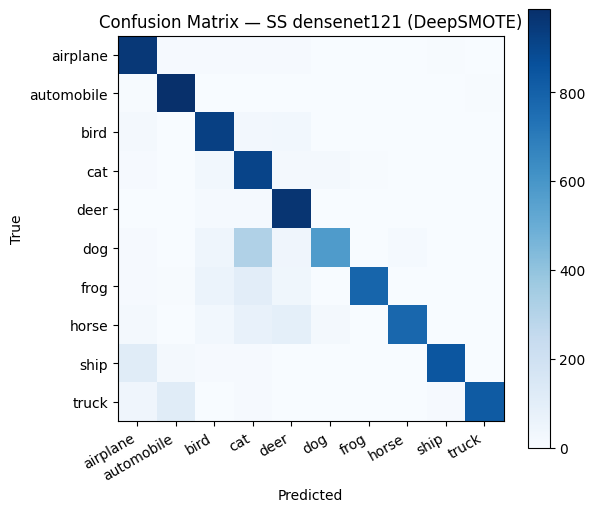

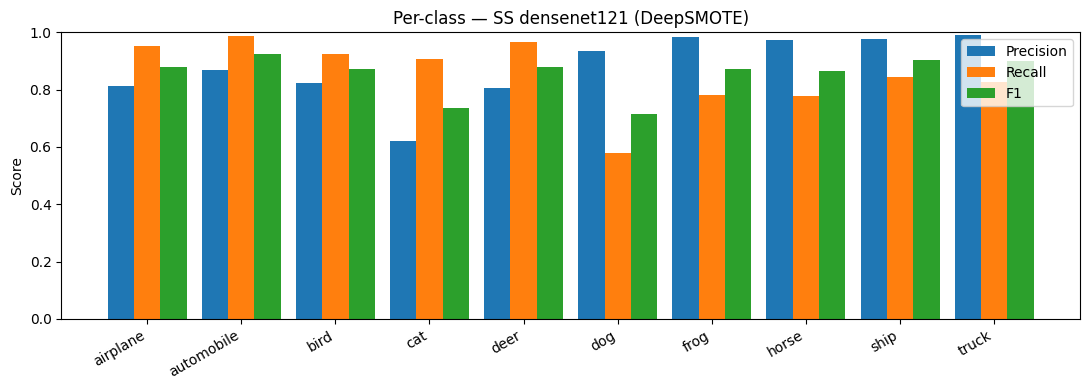


SCENARIO: AS  (num train images = 9500)
Class counts: {0: 5000, 1: 500, 2: 500, 3: 500, 4: 500, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500}

>>> Training DeepSMOTE Autoencoder ...
AE training on 8550 images, AE validation on 950 images.
[AE] Ep 001 | train_loss=0.6222 | val_loss=0.2122
[AE] Ep 005 | train_loss=0.4345 | val_loss=0.2471
[AE] Ep 010 | train_loss=0.3811 | val_loss=0.2851
[AE] Ep 015 | train_loss=0.3566 | val_loss=0.2934
[AE] Ep 020 | train_loss=0.3411 | val_loss=0.2907

>>> Collecting latents per class ...

>>> Generating DeepSMOTE synthetic images ...
Original class counts: {0: 5000, 1: 500, 2: 500, 3: 500, 4: 500, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500}
Target count per class: 4000 (target_ratio=0.8)
Class 1 (automobile): adding 3500 synthetic samples
Class 2 (bird): adding 3500 synthetic samples
Class 3 (cat): adding 3500 synthetic samples
Class 4 (deer): adding 3500 synthetic samples
Class 5 (dog): adding 3500 synthetic samples
Class 6 (frog): adding 3500 synthetic sample

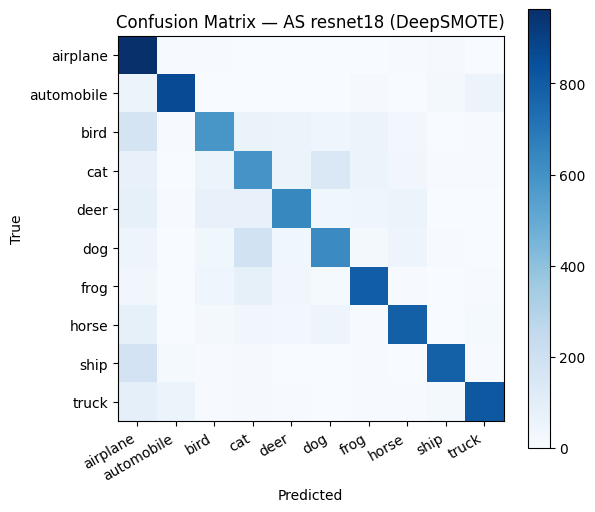

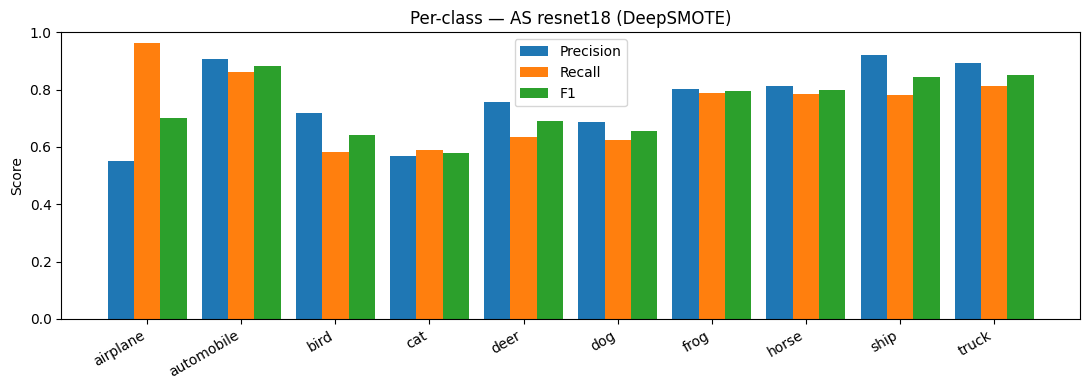


----------------------------------------------------------------------
AS | densenet121 | DeepSMOTE
[Epoch 001/50] train_loss=1.6080 acc=28.98% | val_loss=1.8632 acc=16.97%
[Epoch 005/50] train_loss=1.0407 acc=48.53% | val_loss=1.3769 acc=31.09%
[Epoch 010/50] train_loss=0.6283 acc=66.75% | val_loss=1.4698 acc=31.15%
[Epoch 015/50] train_loss=0.4605 acc=74.77% | val_loss=1.2172 acc=38.45%
[Epoch 020/50] train_loss=0.3382 acc=80.63% | val_loss=1.2071 acc=41.39%
[Epoch 025/50] train_loss=0.2487 acc=85.64% | val_loss=1.0584 acc=51.79%
[Epoch 030/50] train_loss=0.1523 acc=90.98% | val_loss=1.1420 acc=50.36%
[Epoch 035/50] train_loss=0.0786 acc=95.34% | val_loss=0.7211 acc=65.01%
[Epoch 040/50] train_loss=0.0344 acc=97.70% | val_loss=0.8372 acc=65.61%
[Epoch 045/50] train_loss=0.0123 acc=99.24% | val_loss=0.8362 acc=69.07%
[Epoch 050/50] train_loss=0.0078 acc=99.51% | val_loss=0.8560 acc=68.72%

TEST — Acc 69.35% | Macro-F1 69.56% | Balanced Acc 69.35%

--- Classification report: AS | dens

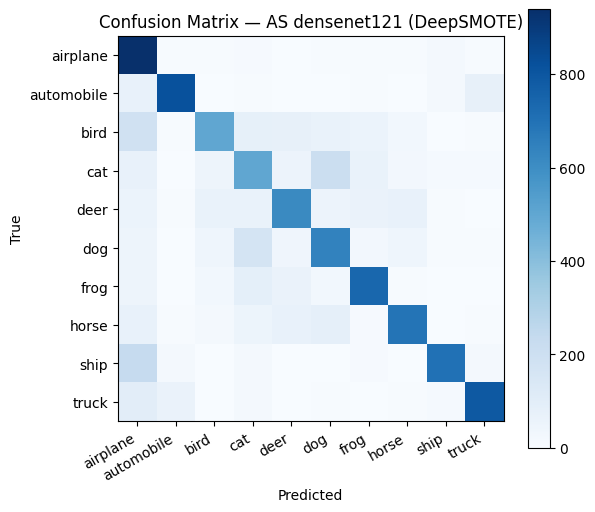

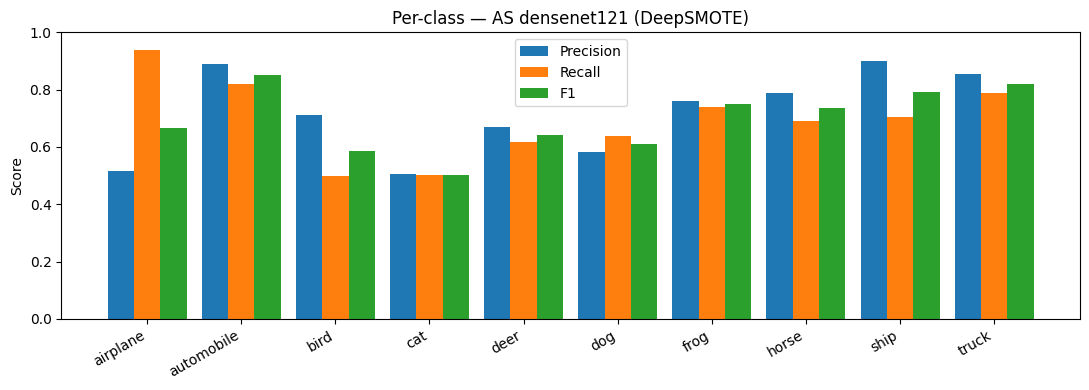


All DeepSMOTE runs finished.


In [ ]:
# =====  Main DeepSMOTE loop for LT / SS / AS & both backbones =====

results_rows = []

for scn_key, split in SPLITS.items():
    if (scn_key=="lt" and not CONFIG["include_lt"]) or \
       (scn_key=="ss" and not CONFIG["include_ss"]) or \
       (scn_key=="as" and not CONFIG["include_as"]):
        continue

    indices = split["indices"]
    counts  = split["counts"]

    print("\n" + "="*90)
    print(f"SCENARIO: {scn_key.upper()}  (num train images = {len(indices)})")
    print("Class counts:", counts)

    # ----- 1) Train DeepSMOTE AE -----
    print("\n>>> Training DeepSMOTE Autoencoder ...")
    ae = train_ae_for_split(
        indices,
        num_epochs=CONFIG["ae_epochs"],
        latent_dim=CONFIG["ae_latent_dim"],
        lambda_penalty=CONFIG["ae_lambda"],
        batch_size=CONFIG["ae_batch_size"],
        val_frac=0.1
    )

    # ----- Collect latents + generate synthetic images -----
    print("\n>>> Collecting latents per class ...")
    latents_per_class = collect_latents_per_class(
        ae, indices, batch_size=256,
        latent_dim=CONFIG["ae_latent_dim"]
    )

    print("\n>>> Generating DeepSMOTE synthetic images ...")
    synthetic_imgs, synthetic_labels = deep_smote_generate(
        ae, latents_per_class,
        latent_dim=CONFIG["ae_latent_dim"],
        target_ratio=CONFIG["target_ratio"]
    )

    syn_dataset = SyntheticImageDataset(synthetic_imgs, synthetic_labels)
    train_subset_imbal = Subset(train_data, indices)
    train_dataset_deepsmote = ConcatDataset([train_subset_imbal, syn_dataset])

    train_loader_deepsmote = DataLoader(
        train_dataset_deepsmote,
        batch_size=BATCH_CLS,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    # -----Classifiers for each backbone -----
    for backbone in CONFIG["backbones"]:
        print("\n" + "-"*70)
        print(f"{scn_key.upper()} | {backbone} | DeepSMOTE")

        model = make_model(backbone, num_classes=num_classes).to(device)

        # Loss: Focal or CE
        if CONFIG["use_focal"]:
            criterion = FocalLoss(gamma=CONFIG["focal_gamma"])
        else:
            criterion = nn.CrossEntropyLoss()

        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=CONFIG["cls_lr"],
            momentum=0.9,
            weight_decay=CONFIG["cls_weight_decay"]
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=CONFIG["cls_epochs"]
        )

        best_acc = -1.0
        best_state = None

        for ep in range(1, CONFIG["cls_epochs"]+1):
            train_loss, train_acc = train_one_epoch(
                model, train_loader_deepsmote,
                criterion, optimizer
            )
            # (Optional) evaluate on test every epoch for logging
            val_loss, val_acc = evaluate(model, test_loader, criterion)
            scheduler.step()

            if val_acc > best_acc:
                best_acc = val_acc
                best_state = {k: v.cpu() for k,v in model.state_dict().items()}

            if ep == 1 or ep % 5 == 0 or ep == CONFIG["cls_epochs"]:
                print(f"[Epoch {ep:03d}/{CONFIG['cls_epochs']}] "
                      f"train_loss={train_loss:.4f} acc={train_acc*100:.2f}% | "
                      f"val_loss={val_loss:.4f} acc={val_acc*100:.2f}%")

        # -----Final test evaluation (best checkpoint) -----
        if best_state is not None:
            model.load_state_dict(best_state)

        y_true, y_pred = get_preds(model, test_loader)
        cm   = confusion_matrix_custom(y_true, y_pred, K=10)
        acc  = (y_true == y_pred).mean()
        mF1  = macro_f1(cm)
        bAcc = balanced_acc(cm)

        tag = "DeepSMOTE"
        print(f"\nTEST — Acc {acc*100:.2f}% | Macro-F1 {mF1*100:.2f}% | "
              f"Balanced Acc {bAcc*100:.2f}%")

        # Classification report
        rep_txt = classification_report(
            y_true, y_pred, target_names=class_labels, digits=2
        )
        print(f"\n--- Classification report: {scn_key.upper()} | {backbone} | {tag} ---")
        print(rep_txt)

        # Save checkpoint
        ckpt_path = os.path.join(PROJ, "ckpts",
                                 f"{backbone}_{scn_key.upper()}_{tag}.pt")
        torch.save(model.state_dict(), ckpt_path)
        print("Saved checkpoint to:", ckpt_path)

        # Save classification report to txt
        rep_path = os.path.join(PROJ, "metrics",
                                f"{backbone}_{scn_key.upper()}_{tag}_report.txt")
        with open(rep_path, "w") as f:
            f.write(rep_txt)
        print("Saved report to:", rep_path)

        # Confusion matrix figure
        plt.figure(figsize=(6.2,5.4))
        plt.imshow(cm, cmap="Blues", interpolation='nearest')
        plt.title(f"Confusion Matrix — {scn_key.upper()} {backbone} ({tag})")
        plt.colorbar()
        ticks = np.arange(len(class_labels))
        plt.xticks(ticks, class_labels, rotation=30, ha='right')
        plt.yticks(ticks, class_labels)
        plt.xlabel('Predicted'); plt.ylabel('True')
        plt.tight_layout()
        fig_cm = os.path.join(PROJ, "figures",
                              f"cm_{backbone}_{scn_key.upper()}_{tag}.png")
        plt.savefig(fig_cm, dpi=180); plt.show()

        # Per-class precision/recall/F1 bar chart
        prec, rec, f1, sup = precision_recall_fscore_support(
            y_true, y_pred, labels=range(10), zero_division=0
        )
        x = np.arange(len(class_labels)); w = 0.28
        plt.figure(figsize=(11,4))
        plt.bar(x-w, prec, width=w, label='Precision')
        plt.bar(x,   rec,  width=w, label='Recall')
        plt.bar(x+w, f1,   width=w, label='F1')
        plt.ylim(0,1.0); plt.legend()
        plt.xticks(x, class_labels, rotation=30, ha='right')
        plt.ylabel("Score")
        plt.title(f"Per-class — {scn_key.upper()} {backbone} ({tag})")
        plt.tight_layout()
        fig_bar = os.path.join(PROJ, "figures",
                               f"perclass_{backbone}_{scn_key.upper()}_{tag}.png")
        plt.savefig(fig_bar, dpi=180); plt.show()

        # Summary row
        results_rows.append([
            scn_key.upper(), backbone, tag,
            round(mF1*100,2), round(bAcc*100,2), round(acc*100,2)
        ])

print("\nAll DeepSMOTE runs finished.")


In [ ]:
# =====  Summary table for DeepSMOTE =====

cols = ["Scenario","Model","Mode","Macro-F1 (%)","Balanced Acc (%)","Overall Acc (%)"]
df_deepsmote = pd.DataFrame(results_rows, columns=cols)
df_deepsmote = df_deepsmote.sort_values(["Scenario","Model","Mode"])
display(df_deepsmote)

out_csv = os.path.join(PROJ, "metrics", "summary_deepsmote.csv")
df_deepsmote.to_csv(out_csv, index=False)
print("Saved DeepSMOTE summary to:", out_csv)


,Scenario,Model,Mode,Macro-F1 (%),Balanced Acc (%),Overall Acc (%)
5,AS,densenet121,DeepSMOTE,69.56,69.35,69.35
4,AS,resnet18,DeepSMOTE,74.43,74.24,74.24
1,LT,densenet121,DeepSMOTE,79.58,79.52,79.52
0,LT,resnet18,DeepSMOTE,79.69,79.61,79.61
3,SS,densenet121,DeepSMOTE,85.47,85.46,85.46
2,SS,resnet18,DeepSMOTE,84.46,84.42,84.42


Saved DeepSMOTE summary to: /content/drive/MyDrive/Imbalance/metrics/summary_deepsmote.csv
